In [1]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import Point

load_dotenv()
TDX_CLIENT_ID = os.getenv("TDX_CLIENT_ID")
TDX_CLIENT_SECRET = os.getenv("TDX_CLIENT_SECRET")

In [2]:
auth_url = "https://tdx.transportdata.tw/auth/realms/TDXConnect/protocol/openid-connect/token"
auth_data = {
    'grant_type': 'client_credentials',
    'client_id': TDX_CLIENT_ID,
    'client_secret': TDX_CLIENT_SECRET
}

response = requests.post(auth_url, data=auth_data)

if response.status_code == 200:
    access_token = response.json().get('access_token')
    print("✅ 成功取得 Access Token！")
else:
    print(f"❌ 取得 Token 失敗: {response.text}")

✅ 成功取得 Access Token！


In [3]:
api_url = "https://tdx.transportdata.tw/api/basic/v2/Bus/EstimatedTimeOfArrival/City/Tainan?%24format=JSON"

headers = {'authorization': f'Bearer {access_token}'}

res = requests.get(api_url, headers=headers)

if res.status_code == 200:
    data = res.json()
    print(f"✅ 成功抓取！當前台南市共有 {len(data)} 筆動態資料。")
else:
    print(f"❌ API 呼叫失敗，狀態碼: {res.status_code}")

✅ 成功抓取！當前台南市共有 9944 筆動態資料。


In [4]:
#整理成 DataFrame 並篩選特定路線
bus_data = []
for item in data:
    bus_data.append({
        'Route_Name': item.get('RouteName', {}).get('Zh_tw'), # 路線名稱
        'Stop_Name': item.get('StopName', {}).get('Zh_tw'),   # 站牌名稱
        'Direction': '去程' if item.get('Direction') == 0 else '返程',
        'Estimate_Time_sec': item.get('EstimateTime'),        # 預估到站時間(秒)
        'Plate_Numb': item.get('PlateNumb')                   # 車牌
    })

# 轉換成表格
df = pd.DataFrame(bus_data)
df.head()  # 顯示前幾筆資料確認格式

,Route_Name,Stop_Name,Direction,Estimate_Time_sec,Plate_Numb
0,綠10,新化區公所,返程,0,None
1,綠10,新化保養廠,返程,0,None
2,綠10,新化站,返程,0,None
3,綠7,中信科技大學,返程,6359,None
4,綠7,永新社區,返程,6396,None


In [5]:
# TDX 的「站位資料 (Station)」API
station_url = "https://tdx.transportdata.tw/api/basic/v2/Bus/Station/City/Tainan?%24format=JSON"

headers = {'authorization': f'Bearer {access_token}'}
res_station = requests.get(station_url, headers=headers)

west_central_stops = set()

if res_station.status_code == 200:
    station_data = res_station.json()
    
    for station in station_data:
        # 尋找行政區為「中西區」的站位
        if station.get('LocationTown') == '中西區':
            # 一個 Station 裡面可能包含多個 Stop (例如雙向的站牌)
            for stop in station.get('Stops', []):
                stop_name = stop.get('StopName', {}).get('Zh_tw')
                if stop_name:
                    west_central_stops.add(stop_name)
                    
    print(f"✅ 成功建檔！中西區內共有 {len(west_central_stops)} 個不重複的公車站牌。")
else:
    print("❌ 站牌清單抓取失敗！")

✅ 成功建檔！中西區內共有 0 個不重複的公車站牌。


In [6]:
# ⚠️ 關鍵篩選：只保留站牌名稱在「中西區名單」內的資料！
df_target = df[df['Stop_Name'].isin(west_central_stops)].copy()

# 剔除還沒發車(NaN)的站點，並換算成分鐘
df_target = df_target.dropna(subset=['Estimate_Time_sec'])
df_target['Estimate_Time_min'] = (df_target['Estimate_Time_sec'] / 60).round(1)

# 依照即將到站時間，由近到遠排序
df_target = df_target.sort_values(by='Estimate_Time_sec')

print(f"\n🚨 【中西區】即將進站的公車總覽 (前 15 筆)：")
display(df_target[['Route_Name', 'Stop_Name', 'Direction', 'Estimate_Time_min', 'Plate_Numb']].head(15))


🚨 【中西區】即將進站的公車總覽 (前 15 筆)：


,Route_Name,Stop_Name,Direction,Estimate_Time_min,Plate_Numb


✅ 下載完成！中西區共有 655 個路口(Nodes)，1849 條路段(Edges)。


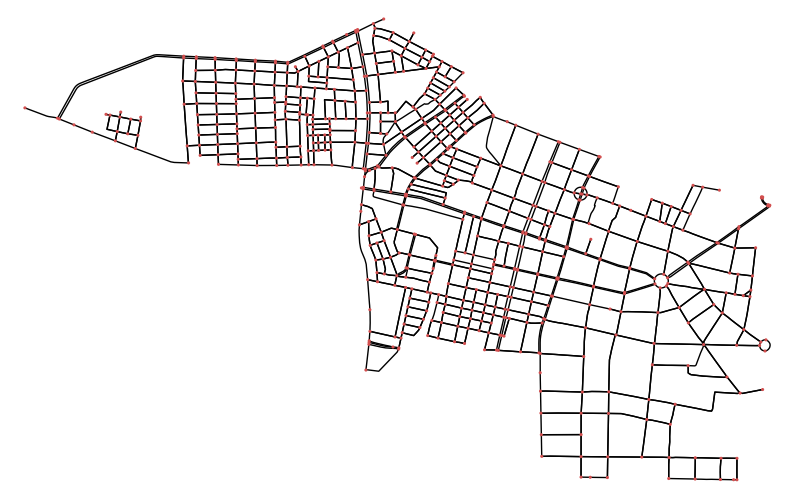

In [7]:
# 設定目標區域
place_name = "中西區, 台南市, 台灣"

# 下載路網圖 (network_type='drive' 代表只抓取汽車可通行的道路，會自動剃除純人行道)
# 這個 G 就是一個包含 Nodes 和 Edges 的數學圖論物件
G = ox.graph_from_place(place_name, network_type='drive')

print(f"✅ 下載完成！中西區共有 {len(G.nodes)} 個路口(Nodes)，{len(G.edges)} 條路段(Edges)。")

# 將路網視覺化畫出來
fig, ax = ox.plot_graph(
    G, 
    figsize=(10, 10),       # 設定圖片大小
    bgcolor="#ffffff",      # 背景顏色改為白色 (#ffffff)
    node_color="#D34F4F",   # 路口節點改為深灰色 (#333333)，確保在白底上清晰可見
    node_size=5,            # 節點大小
    edge_color="#000000",   # 路段改為黑色 (#000000)
    edge_linewidth=1        # 道路線條寬度
)

C:\Users\symba\AppData\Local\Temp\ipykernel_5760\2730667534.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  district_boundary = district_gdf.unary_union


✅ 成功過濾出 80 個位於中西區內的站牌。
✅ 已將站牌轉化為路網中的 75 個風險節點。


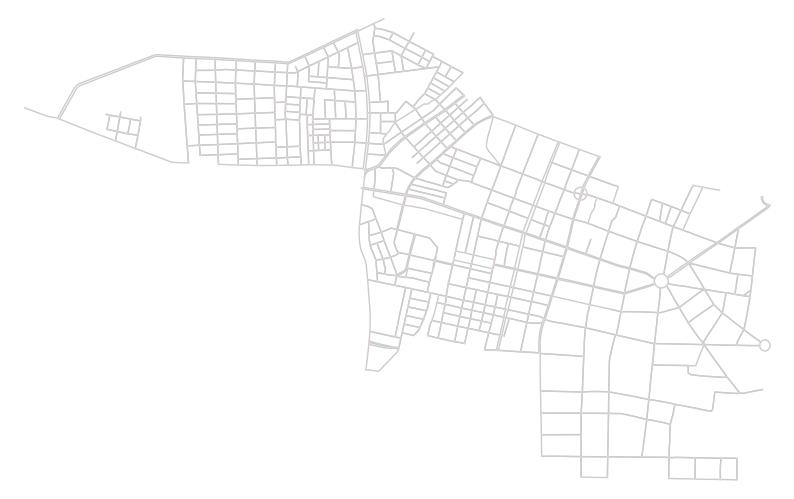

In [8]:
# 取得中西區邊界，並將站牌座標精準對位至路網節點

district_gdf = ox.geocode_to_gdf(place_name)
district_boundary = district_gdf.unary_union 

stop_coords = {}
if res_station.status_code == 200:
    for station in res_station.json():
        # 修正後的層級：直接從 StationPosition 抓取
        pos = station.get('StationPosition', {})
        lat, lon = pos.get('PositionLat'), pos.get('PositionLon')
        name = station.get('StationName', {}).get('Zh_tw')
        
        if name and lat and lon:
            # 幾何過濾：確保點在中西區行政區劃內
            point = Point(lon, lat)
            if point.within(district_boundary):
                stop_coords[name] = (lon, lat)
    
    print(f"✅ 成功過濾出 {len(stop_coords)} 個位於中西區內的站牌。")
else:
    print(f"❌ API 連線失敗，請檢查 Token。")

# 3. 空間對位：將站牌「吸附」到最近的路網節點 (Node)
stop_nodes = {}
if stop_coords:
    for stop_name, (lon, lat) in stop_coords.items():
        # 尋找路網 G 中最近的節點 ID
        nearest_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
        stop_nodes[stop_name] = nearest_node
    print(f"✅ 已將站牌轉化為路網中的 {len(set(stop_nodes.values()))} 個風險節點。")

# --- 繪圖驗證 ---
fig, ax = ox.plot_graph(G, figsize=(10, 10), bgcolor="#ffffff", node_color="#E8D2D2", 
                        node_size=2, edge_color="#cccccc", show=False, close=False)

# 將綁定後的節點畫成紅點 (這保證一定在地圖的線上/點上)
node_x = [G.nodes[n]['x'] for n in stop_nodes.values()]
node_y = [G.nodes[n]['y'] for n in stop_nodes.values()]

In [9]:
stop_nodes = {}

for stop_name, (lon, lat) in stop_coords.items():
    # 找出距離該經緯度最近的路口 Node ID
    nearest_node = ox.distance.nearest_nodes(G, X=lon, Y=lat)
    stop_nodes[stop_name] = nearest_node

print(f"✅ 成功綁定 {len(stop_nodes)} 個站牌！")
if '神農街' in stop_nodes:
    print(f"👉 【神農街】站對應的 Node ID: {stop_nodes['神農街']}")

✅ 成功綁定 80 個站牌！
👉 【神農街】站對應的 Node ID: 1709220981


In [10]:
# 1. 初始化：所有路段預設權重 = 實際長度
for u, v, k, data in G.edges(keys=True, data=True):
    data['dynamic_cost'] = data['length']

# 2. 模擬風險：假設神農街目前有公車停靠
target_stop = '神農街'

if target_stop in stop_nodes:
    risk_node = stop_nodes[target_stop]
    # 設定一個極大的懲罰值 (例如 5000 公尺)，強迫演算法繞道
    penalty = 5
    
    # 找出所有連接到該風險路口的街道
    for u, v, k, data in G.edges(keys=True, data=True):
        if u == risk_node or v == risk_node:
            data['dynamic_cost'] += penalty
            
    print(f"🚨 風險觸發：【{target_stop}】節點已加上阻力懲罰 (+{penalty}m)")
else:
    print(f"⚠️ 找不到 {target_stop} 的對應節點，請確認 Cell 8 是否成功執行。")

🚨 風險觸發：【神農街】節點已加上阻力懲罰 (+5m)


傳統路徑長度: 616.9 公尺
避險路徑長度: 616.9 公尺
⚠️ 警告：兩條路徑相同！這代表神農街周邊可能全是單行道，無路可繞。
🟠 橘色 X 為模擬的公車風險點


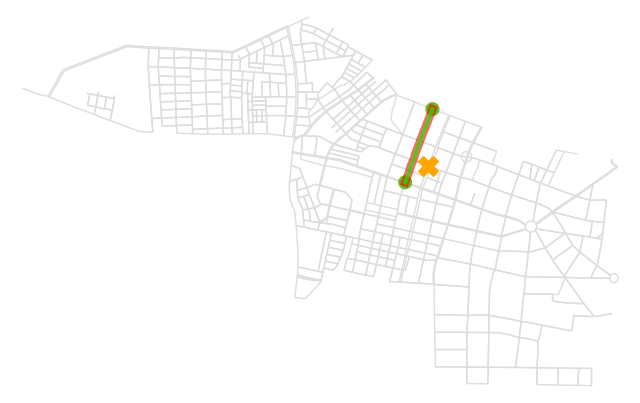

In [11]:
import networkx as nx

# 重新選定一組「跨越神農街」的起終點
# 起點：海安路二段附近 / 終點：民權路三段附近
orig = ox.distance.nearest_nodes(G, X=120.1969, Y=23.0001) 
dest = ox.distance.nearest_nodes(G, X=120.1950, Y=22.9960)

try:
    # 🔴 計算傳統路徑
    route_trad = nx.shortest_path(G, orig, dest, weight='length')
    # 🟢 計算避險路徑
    route_safe = nx.shortest_path(G, orig, dest, weight='dynamic_cost')

    print(f"傳統路徑長度: {nx.path_weight(G, route_trad, 'length'):.1f} 公尺")
    print(f"避險路徑長度: {nx.path_weight(G, route_safe, 'length'):.1f} 公尺")

    if route_trad == route_safe:
        print("⚠️ 警告：兩條路徑相同！這代表神農街周邊可能全是單行道，無路可繞。")
    
    # --- 繪圖強化 ---
    # 同時畫出兩條路線，並設定 alpha 透明度，這樣重疊時會變色
    fig, ax = ox.plot_graph_routes(
        G, 
        routes=[route_trad, route_safe], 
        route_colors=['red', 'lime'], 
        route_linewidths=[6, 3], # 讓紅線粗一點，綠線細一點，重疊時紅邊會露出來
        route_alpha=0.6,
        node_size=0,
        bgcolor='#ffffff',
        edge_color='#dddddd',
        show=False,
        close=False
    )
    
    # 把我們設定風險的「紅點」也標上去，看綠線有沒有繞開它
    risk_node = stop_nodes['神農街']
    ax.scatter(G.nodes[risk_node]['x'], G.nodes[risk_node]['y'], c='orange', s=200, marker='X', label='Danger', zorder=5)
    
    print("🟠 橘色 X 為模擬的公車風險點")
    import matplotlib.pyplot as plt
    plt.show()

except Exception as e:
    print(f"❌ 錯誤: {e}")

In [12]:
%%writefile layer2_bus.py
import requests
import osmnx as ox
from shapely.geometry import Point

def apply_bus_risk(G, client_id, client_secret):
    """
    ✨ 關鍵修正：這裡現在接收 G, client_id, client_secret 共三個參數
    """
    print("🚌 [Layer 2] 正在自動換發 Token 並掃描風險...")
    
    # 1. 自動換 Token
    auth_url = "https://tdx.transportdata.tw/auth/realms/TDXConnect/protocol/openid-connect/token"
    auth_data = {
        'grant_type': 'client_credentials',
        'client_id': client_id,
        'client_secret': client_secret
    }
    
    try:
        auth_res = requests.post(auth_url, data=auth_data)
        auth_res.raise_for_status()
        token = auth_res.json().get('access_token')
    except Exception as e:
        print(f"❌ Token 取得失敗: {e}")
        return G

    # 2. 抓取站牌資料
    headers = {'authorization': f'Bearer {token}'}
    station_url = "https://tdx.transportdata.tw/api/basic/v2/Bus/Station/City/Tainan?%24format=JSON"
    
    try:
        res = requests.get(station_url, headers=headers)
        data = res.json()
        
        # 取得邊界過濾
        district_gdf = ox.geocode_to_gdf("中西區, 台南市, 台灣")
        district_boundary = district_gdf.unary_union.buffer(0.005)
        
        stop_nodes = []
        for station in data:
            pos = station.get('StationPosition', {})
            lat, lon = pos.get('PositionLat'), pos.get('PositionLon')
            if lat and lon and Point(lon, lat).within(district_boundary):
                stop_nodes.append(ox.distance.nearest_nodes(G, X=lon, Y=lat))
        
        # 3. 注入風險
        unique_stops = set(stop_nodes)
        for u, v, k, d in G.edges(keys=True, data=True):
            if u in unique_stops or v in unique_stops:
                d['dynamic_cost'] += 10000
        print(f"🚨 [Layer 2] 成功！已處理 {len(unique_stops)} 個風險點")
        
    except Exception as e:
        print(f"❌ 資料抓取失敗: {e}")
            
    return G

Writing layer2_bus.py
